# 在本练习中，我们将梳理matplotlib中几个常见的小问题。
每幅图的下方是对代码要点的讲解。

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline

### 1. How to draw 2 scatterplots in different panels?

Let’s understand figure and axes in little more detail.

Suppose, I want to draw our two sets of points (green rounds and blue stars) in two separate plots side-by-side instead of the same plot. How would you do that?

You can do that by creating two separate subplots, a.k.a., axes using plt.subplots(1, 2). This creates and returns two objects:
* the figure
* the axes (subplots) inside the figure

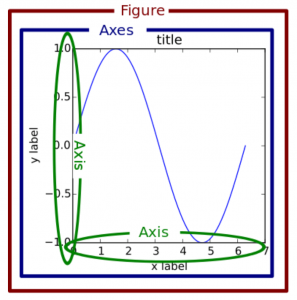

In [3]:
from IPython.display import Image
Image("plt and ax.png",width=200,height=200)

Previously, I called plt.plot() to draw the points. Since there was only one axes by default, it drew the points on that axes itself.

But now, since you want the points drawn on different subplots (axes), you have to call the plot function in the respective axes (ax1 and ax2 in below code) instead of plt.

Notice in below code, I call ax1.plot() and ax2.plot() instead of calling plt.plot() twice.

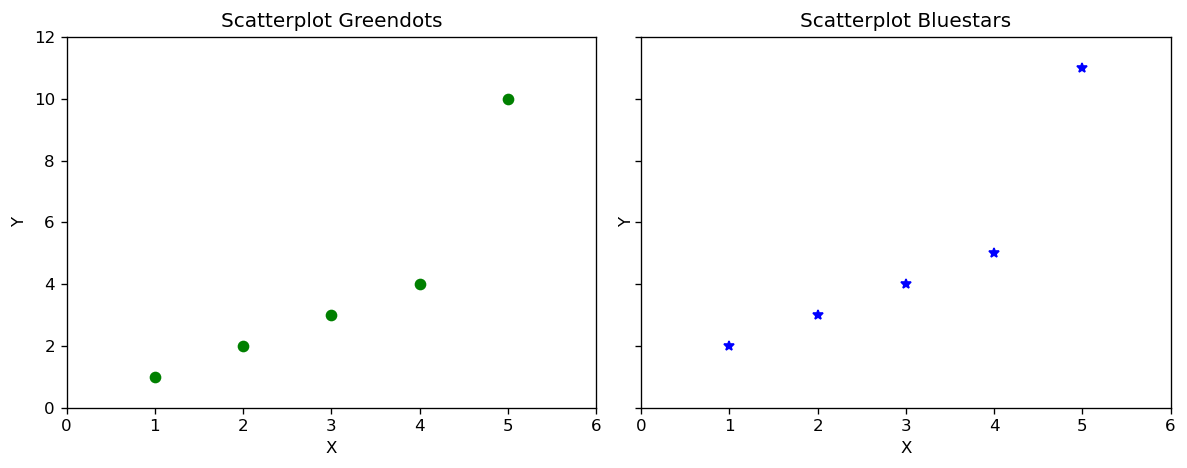

In [4]:
# Create Figure and Subplots
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,4), sharey=True, dpi=120)

# Plot
ax1.plot([1,2,3,4,5], [1,2,3,4,10], 'go')  # green dots
ax2.plot([1,2,3,4,5], [2,3,4,5,11], 'b*')  # blue stars

# Title, X and Y labels, X and Y Lim
ax1.set_title('Scatterplot Greendots'); ax2.set_title('Scatterplot Bluestars')
ax1.set_xlabel('X');  ax2.set_xlabel('X')  # x label
ax1.set_ylabel('Y');  ax2.set_ylabel('Y')  # y label
ax1.set_xlim(0, 6) ;  ax2.set_xlim(0, 6)   # x axis limits
ax1.set_ylim(0, 12);  ax2.set_ylim(0, 12)  # y axis limits

# ax2.yaxis.set_ticks_position('none') 
plt.tight_layout()
plt.show()

Setting sharey=True in plt.subplots() shares the Y axis between the two subplots.

And dpi=120 increased the number of dots per inch of the plot to make it look more sharp and clear. You will notice a distinct improvement in clarity on increasing the dpi especially in jupyter notebooks.

Thats sounds like a lot of functions to learn. Well it’s quite easy to remember it actually.

The ax1 and ax2 objects, like plt, has equivalent set_title, set_xlabel and set_ylabel functions. In fact, the plt.title() actually calls the current axes set_title() to do the job.

* plt.xlabel() ? ax.set_xlabel()
* plt.ylabel() ? ax.set_ylabel()
* plt.xlim() ? ax.set_xlim()
* plt.ylim() ? ax.set_ylim()
* plt.title() ? ax.set_title()

Alternately, to save keystrokes, you can set multiple things in one go using the ax.set().

In [5]:
ax1.set(title='Scatterplot Greendots', xlabel='X', ylabel='Y', xlim=(0,6), ylim=(0,12))
ax2.set(title='Scatterplot Bluestars', xlabel='X', ylabel='Y', xlim=(0,6), ylim=(0,12))

[Text(0.5, 1.0, 'Scatterplot Bluestars'),
 Text(0.5, 26.999999999999996, 'X'),
 Text(634.4583333333331, 0.5, 'Y'),
 (0.0, 6.0),
 (0.0, 12.0)]

# 2. Object Oriented Syntax vs Matlab like Syntax

A known ‘problem’ with learning matplotlib is, it has two coding interfaces:

* Matlab like syntax
* Object oriented syntax.

This is partly the reason why matplotlib doesn’t have one consistent way of achieving the same given output, making it a bit difficult to understand for new comers.

The syntax you’ve seen so far is the Object-oriented syntax, which I personally prefer and is more intuitive and pythonic to work with.

However, since the original purpose of matplotlib was to recreate the plotting facilities of matlab in python, the matlab-like-syntax is retained and still works.

The matlab syntax is ‘stateful’.

That means, the plt keeps track of what the current axes is. So whatever you draw with plt.{anything} will reflect only on the current subplot.

Practically speaking, the main difference between the two syntaxes is, in matlab-like syntax, all plotting is done using plt methods instead of the respective axes‘s method as in object oriented syntax.

So, how to recreate the above multi-subplots figure (or any other figure for that matter) using matlab-like syntax?

The general procedure is: You manually create one subplot at a time (using plt.subplot() or plt.add_subplot()) and immediately call plt.plot() or plt.{anything} to modify that specific subplot (axes). Whatever method you call using plt will be drawn in the current axes.

The code below shows this in practice:

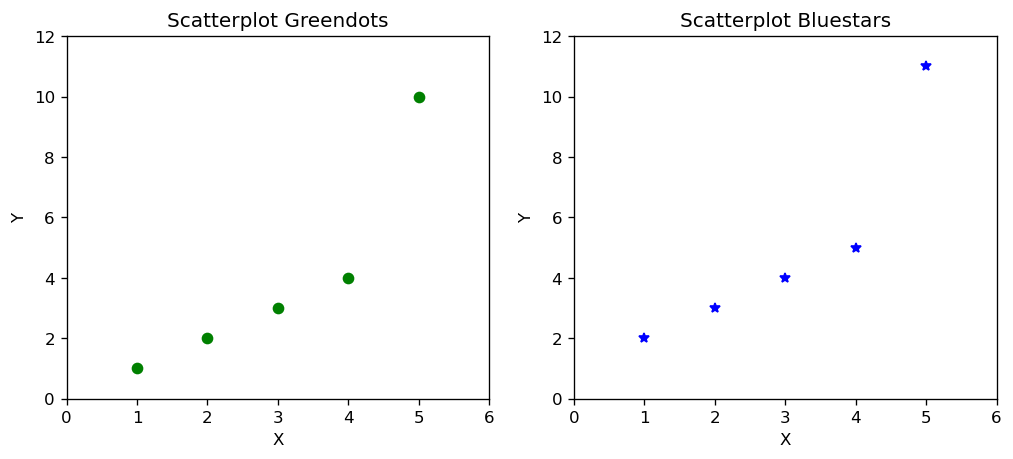

In [6]:
plt.figure(figsize=(10,4), dpi=120) # 10 is width, 4 is height

# Left hand side plot
plt.subplot(1,2,1)  # (nRows, nColumns, axes number to plot)
plt.plot([1,2,3,4,5], [1,2,3,4,10], 'go')  # green dots
plt.title('Scatterplot Greendots')  
plt.xlabel('X'); plt.ylabel('Y')
plt.xlim(0, 6); plt.ylim(0, 12)

# Right hand side plot
plt.subplot(1,2,2)
plt.plot([1,2,3,4,5], [2,3,4,5,11], 'b*')  # blue stars
plt.title('Scatterplot Bluestars')  
plt.xlabel('X'); plt.ylabel('Y')
plt.xlim(0, 6); plt.ylim(0, 12)
plt.show()

Let’s breakdown the above piece of code.

In plt.subplot(1,2,1), the first two values, that is (1,2) specifies the number of rows (1) and columns (2) and the third parameter (1) specifies the position of current subplot. The subsequent plt functions, will always draw on this current subplot.

You can get a reference to the current (subplot) axes with plt.gca() and the current figure with plt.gcf(). Likewise, plt.cla() and plt.clf() will clear the current axes and figure respectively.

Alright, compare the above code with the object oriented (OO) version. The OO version might look a bit confusing because it has a mix of both ax1 and plt commands.

However, there is a significant advantage with axes approach.

That is, since plt.subplots returns all the axes as separate objects, you can avoid writing repetitive code by looping through the axes.

Always remember: plt.plot() or plt.{anything} will always act on the plot in the current axes, whereas, ax.{anything} will modify the plot inside that specific ax.

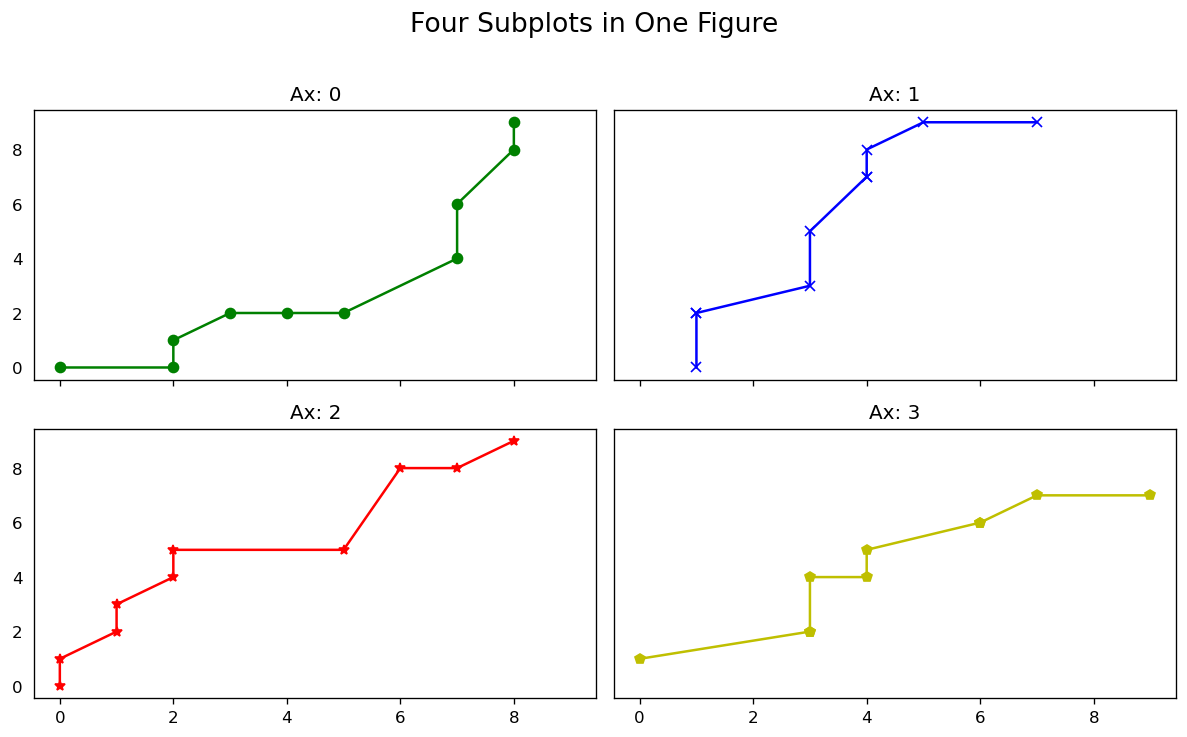

In [11]:
# Draw multiple plots using for-loops using object oriented syntax
import numpy as np
from numpy.random import seed, randint
seed(100)

# Create Figure and Subplots
fig, axes = plt.subplots(2,2, figsize=(10,6), sharex=True, sharey=True, dpi=120)

# Define the colors and markers to use
colors = {0:'g', 1:'b', 2:'r', 3:'y'}
markers = {0:'o', 1:'x', 2:'*', 3:'p'}

# Plot each axes
for i, ax in enumerate(axes.ravel()):
    ax.plot(sorted(randint(0,10,10)), sorted(randint(0,10,10)), marker=markers[i], color=colors[i])  
    ax.set_title('Ax: ' + str(i))
    ax.yaxis.set_ticks_position('none')

plt.suptitle('Four Subplots in One Figure',  verticalalignment='bottom', fontsize=16)    
plt.tight_layout()
plt.show()

Did you notice in the above plot, the Y-axis does not have ticks?

That’s because I used ax.yaxis.set_ticks_position('none') to turn off the Y-axis ticks. This is another advantage of the object-oriented interface. You can actually get a reference to any specific element of the plot and use its methods to manipulate it.

Can you guess how to turn off the X-axis ticks?

The plt.suptitle() added the main title at the figure level title. plt.title() would have done the same for the current subplot (axes).

The verticalalignment='bottom' parameter denotes the **hingepoint** should be at the bottom of the title text, so that the main title is pushed slightly upwards. （注：hingepoint 可理解为**标题文本**位置的参照点，[plt.suptitle()](https://matplotlib.org/3.5.1/api/_as_gen/matplotlib.pyplot.suptitle.html) 中 hingepoint 相对于图的位置默认是x=0.5,y=0.98 ，所以默认情况下 verticalalignment='bottom' 意味着**标题文本**的**下方**与y=0.98对齐，所以相较于verticalalignment='top'，标题位置会上移一个文本的高度。）

Alright, What you’ve learned so far is the core essence of how to create a plot and manipulate it using matplotlib. Next, let’s see how to get the reference to and modify the other components of the plot

# 3. How to Modify the Axis Ticks Positions and Labels

There are 3 basic things you will probably ever need in matplotlib when it comes to manipulating axis ticks:
1. How to control the position and tick labels? (using plt.xticks() or ax.setxticks() and ax.setxticklabels())
2. How to control which axis’s ticks (top/bottom/left/right) should be displayed (using plt.tick_params())
3. Functional formatting of tick labels

If you are using ax syntax, you can use ax.set_xticks() and ax.set_xticklabels() to set the positions and label texts respectively. If you are using the plt syntax, you can set both the positions as well as the label text in one call using the plt.xticks().

Actually, if you look at the code of plt.xticks() method (by typing ??plt.xticks in jupyter notebook), it calls ax.set_xticks() and ax.set_xticklabels() to do the job. plt.xticks takes the ticks and labels as required parameters but you can also adjust the label’s fontsize, rotation, ‘horizontalalignment’ and ‘verticalalignment’ of the hinge points on the labels, like I’ve done in the below example.

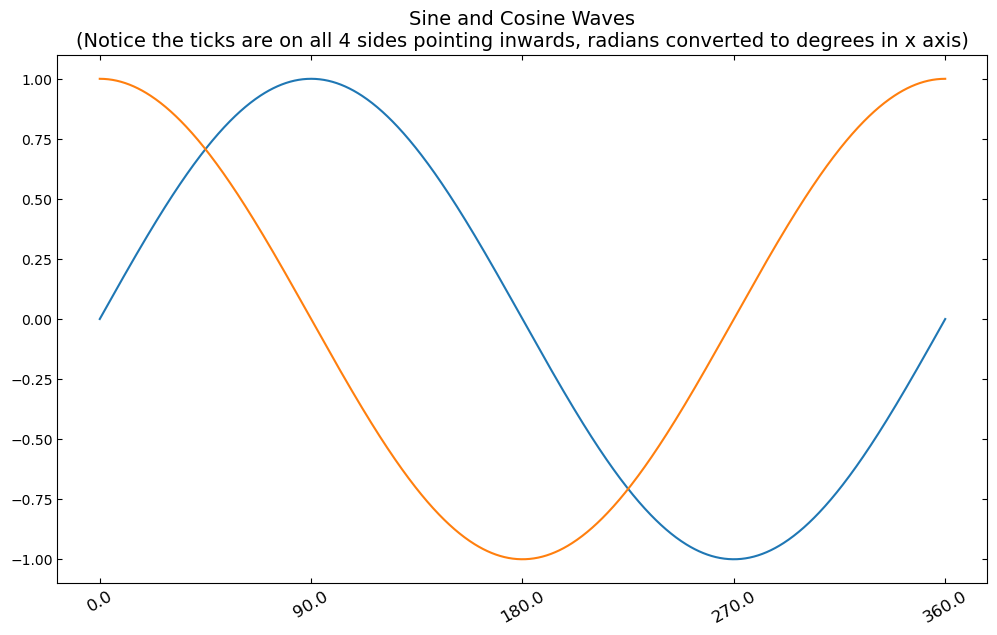

In [7]:
from matplotlib.ticker import FuncFormatter

# 1 radian = 57.2985 degrees
def rad_to_degrees(x, pos):
    'converts radians to degrees'
    return round(x * 57.2985, 2)

plt.figure(figsize=(12,7), dpi=100)
X = np.linspace(0,2*np.pi,1000)
plt.plot(X,np.sin(X))
plt.plot(X,np.cos(X))

# 1. Adjust x axis Ticks
plt.xticks(ticks=np.arange(0, 440/57.2985, 90/57.2985), fontsize=12, rotation=30, ha='center', va='top')  # 1 radian = 57.2985 degrees

# 2. Tick Parameters
plt.tick_params(axis='both',bottom=True, top=True, left=True, right=True, direction='in', which='major', grid_color='blue')

# 3. Format tick labels to convert radians to degrees
formatter = FuncFormatter(rad_to_degrees)
plt.gca().xaxis.set_major_formatter(formatter)

# plt.grid(linestyle='--', linewidth=0.5, alpha=0.15)
plt.title('Sine and Cosine Waves\n(Notice the ticks are on all 4 sides pointing inwards, radians converted to degrees in x axis)', fontsize=14)
plt.show()

In above code, plt.tick_params() is used to determine which all axis of the plot (‘top’ / ‘bottom’ / ‘left’ / ‘right’) you want to draw the ticks and which direction (‘in’ / ‘out’) the tick should point to.

the matplotlib.ticker module provides the FuncFormatter to determine how the final tick label should be shown.

# 4. Understanding the rcParams, Colors and Plot Styles

The look and feel of various components of a matplotlib plot can be set globally using rcParams. The complete list of rcParams can be viewed by typing:

In [8]:
import matplotlib as mpl
mpl.rc_params()
# RcParams({'_internal.classic_mode': False,
#           'agg.path.chunksize': 0,
#           'animation.avconv_args': [],
#           'animation.avconv_path': 'avconv',
#           'animation.bitrate': -1,
#           'animation.codec': 'h264',
#           ... TRUNCATED LaRge OuTPut ...

RcParams({'_internal.classic_mode': False,
          'agg.path.chunksize': 0,
          'animation.avconv_args': [],
          'animation.avconv_path': 'avconv',
          'animation.bitrate': -1,
          'animation.codec': 'h264',
          'animation.convert_args': [],
          'animation.convert_path': 'convert',
          'animation.embed_limit': 20.0,
          'animation.ffmpeg_args': [],
          'animation.ffmpeg_path': 'ffmpeg',
          'animation.frame_format': 'png',
          'animation.html': 'none',
          'animation.html_args': [],
          'animation.writer': 'ffmpeg',
          'axes.autolimit_mode': 'data',
          'axes.axisbelow': 'line',
          'axes.edgecolor': 'black',
          'axes.facecolor': 'white',
          'axes.formatter.limits': [-5, 6],
          'axes.formatter.min_exponent': 0,
          'axes.formatter.offset_threshold': 4,
          'axes.formatter.use_locale': False,
          'axes.formatter.use_mathtext': False,
          'axes.f

You can adjust the params you’d like to change by updating it. The below snippet adjusts the font by setting it to ‘stix’, which looks great on plots by the way.

In [9]:
mpl.rcParams.update({'font.size': 18, 'font.family': 'STIXGeneral', 'mathtext.fontset': 'stix'})

After modifying a plot, you can rollback the rcParams to default setting using:

In [10]:
mpl.rcParams.update(mpl.rcParamsDefault)  # reset to defaults

Matplotlib comes with pre-built styles which you can look by typing:

In [11]:
plt.style.available
# ['seaborn-dark', 'seaborn-darkgrid', 'seaborn-ticks', 'fivethirtyeight',
#  'seaborn-whitegrid', 'classic', '_classic_test', 'fast', 'seaborn-talk',
#  'seaborn-dark-palette', 'seaborn-bright', 'seaborn-pastel', 'grayscale',
#  'seaborn-notebook', 'ggplot', 'seaborn-colorblind', 'seaborn-muted',
#  'seaborn', 'Solarize_Light2', 'seaborn-paper', 'bmh', 'tableau-colorblind10',
#  'seaborn-white', 'dark_background', 'seaborn-poster', 'seaborn-deep']

['Solarize_Light2',
 '_classic_test_patch',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'seaborn',
 'seaborn-bright',
 'seaborn-colorblind',
 'seaborn-dark',
 'seaborn-dark-palette',
 'seaborn-darkgrid',
 'seaborn-deep',
 'seaborn-muted',
 'seaborn-notebook',
 'seaborn-paper',
 'seaborn-pastel',
 'seaborn-poster',
 'seaborn-talk',
 'seaborn-ticks',
 'seaborn-white',
 'seaborn-whitegrid',
 'tableau-colorblind10']

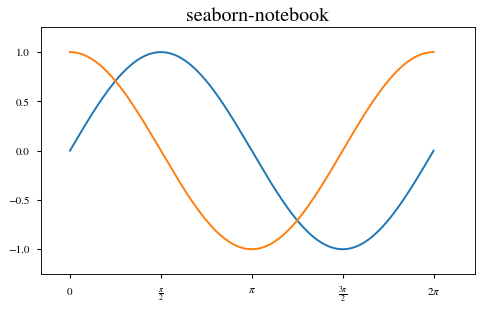

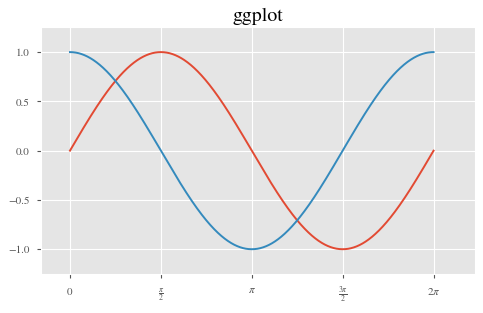

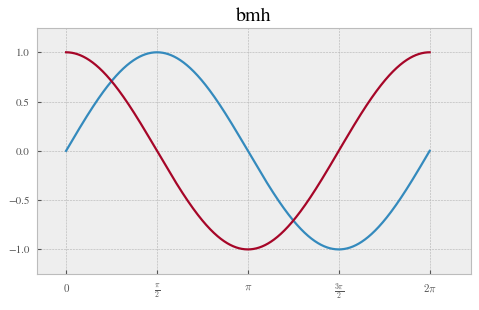

In [12]:
import matplotlib as mpl
mpl.rcParams.update({'font.size': 18, 'font.family': 'STIXGeneral', 'mathtext.fontset': 'stix'})

def plot_sine_cosine_wave(style='ggplot'):
    plt.style.use(style)
    plt.figure(figsize=(7,4), dpi=80)
    X = np.linspace(0,2*np.pi,1000)
    plt.plot(X,np.sin(X)); plt.plot(X,np.cos(X))
    plt.xticks(ticks=np.arange(0, 440/57.2985, 90/57.2985), labels = [r'$0$',r'$\frac{\pi}{2}$',r'$\pi$',r'$\frac{3\pi}{2}$',r'$2\pi$'])  # 1 radian = 57.2985 degrees
    plt.gca().set(ylim=(-1.25, 1.25), xlim=(-.5, 7))
    plt.title(style, fontsize=18)
    plt.show()

plot_sine_cosine_wave('seaborn-notebook')    
plot_sine_cosine_wave('ggplot')    
plot_sine_cosine_wave('bmh')    

# 5. How to customize matplotlib’s subplots layout?

Matplotlib provides two convenient ways to create customized multi-subplots layout.
* plt.subplot2grid
* plt.GridSpec

Both plt.subplot2grid and plt.GridSpec lets you draw complex layouts. Below is a nice plt.subplot2grid example.

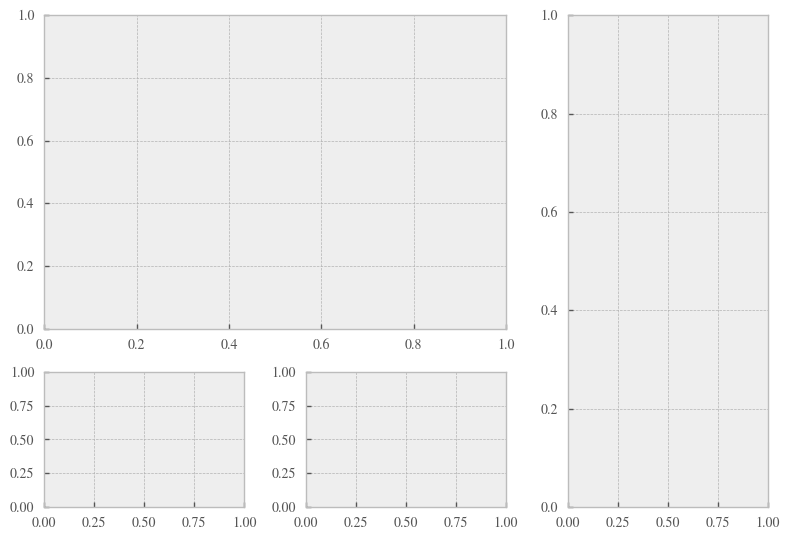

In [13]:
# Supplot2grid approach
fig = plt.figure()
ax1 = plt.subplot2grid((3,3), (0,0), colspan=2, rowspan=2) # topleft
ax3 = plt.subplot2grid((3,3), (0,2), rowspan=3)            # right
ax4 = plt.subplot2grid((3,3), (2,0))                       # bottom left
ax5 = plt.subplot2grid((3,3), (2,1))                       # bottom right
fig.tight_layout()

Using plt.GridSpec, you can use either a plt.subplot() interface which takes part of the grid specified by plt.GridSpec(nrow, ncol) or use the ax = fig.add_subplot(g) where the GridSpec is defined by height_ratios and weight_ratios.

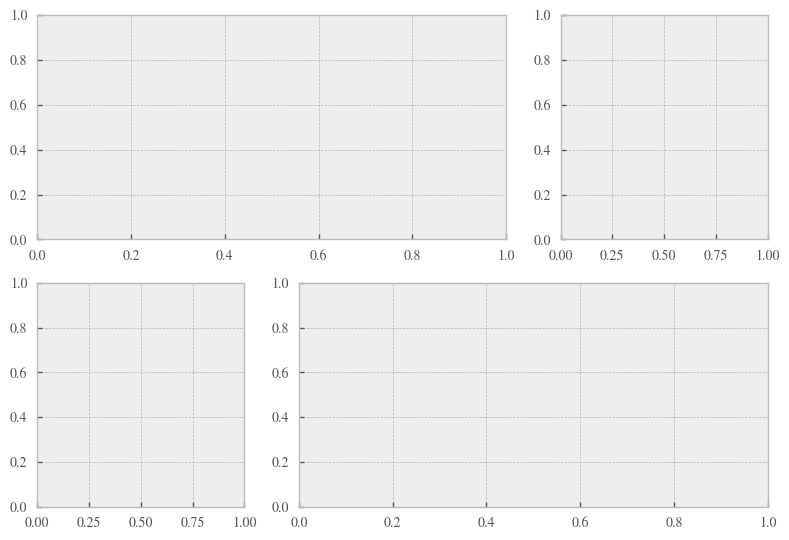

In [14]:
# GridSpec Approach 1
import matplotlib.gridspec as gridspec
fig = plt.figure()
grid = plt.GridSpec(2, 3)  # 2 rows 3 cols
plt.subplot(grid[0, :2])  # top left
plt.subplot(grid[0, 2])   # top right
plt.subplot(grid[1, :1])  # bottom left
plt.subplot(grid[1, 1:])  # bottom right
fig.tight_layout()

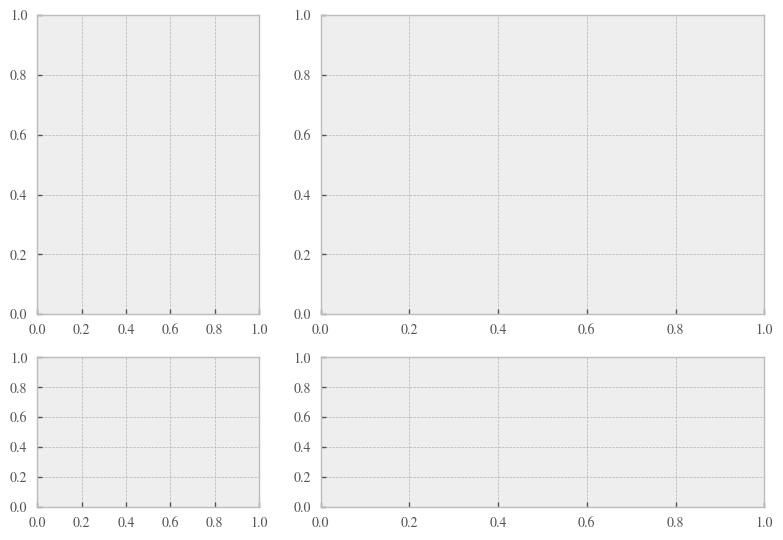

In [15]:
# GridSpec Approach 2
import matplotlib.gridspec as gridspec
fig = plt.figure()
gs = gridspec.GridSpec(2, 2, height_ratios=[2,1], width_ratios=[1,2])
for g in gs:
    ax = fig.add_subplot(g)    
fig.tight_layout()

The above examples showed layouts where the subplots dont overlap. It is possible to make subplots to overlap. In fact, you can draw an axes inside a larger axes using fig.add_axes(). You need to specify the x,y positions relative to the figure and also the width and height of the inner plot.

Below is an example of an inner plot that zooms in to a larger plot.

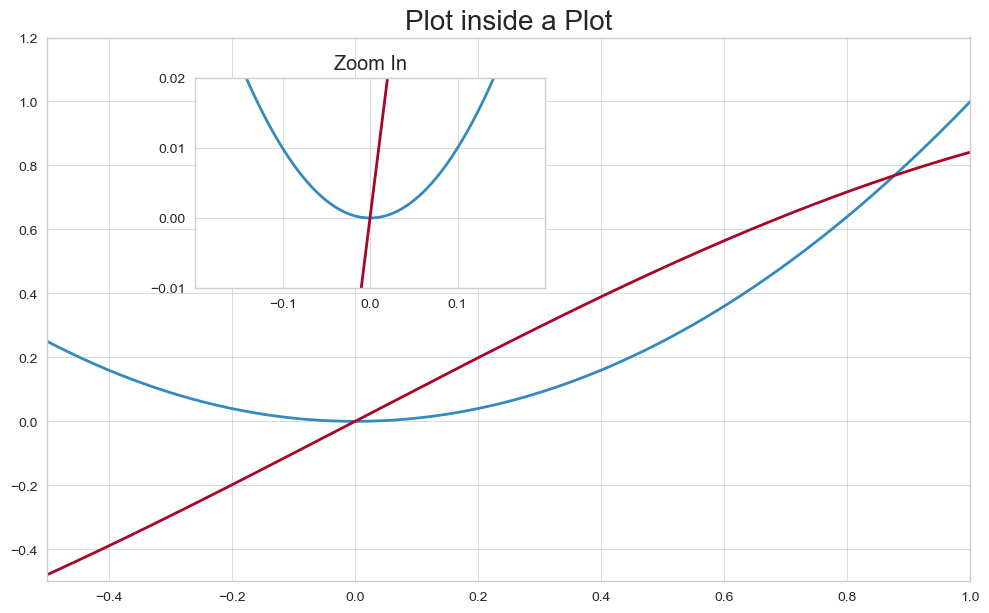

In [16]:
# Plot inside a plot
plt.style.use('seaborn-whitegrid')
fig, ax = plt.subplots(figsize=(10,6))
x = np.linspace(-0.50, 1., 1000)

# Outer Plot
ax.plot(x, x**2)
ax.plot(x, np.sin(x))
ax.set(xlim=(-0.5, 1.0), ylim=(-0.5,1.2))
fig.tight_layout()

# Inner Plot
inner_ax = fig.add_axes([0.2, 0.55, 0.35, 0.35]) # x, y, width, height
inner_ax.plot(x, x**2)
inner_ax.plot(x, np.sin(x))
inner_ax.set(title='Zoom In', xlim=(-.2, .2), ylim=(-.01, .02), 
             yticks = [-0.01, 0, 0.01, 0.02], xticks=[-0.1,0,.1])
ax.set_title("Plot inside a Plot", fontsize=20)
plt.show()
mpl.rcParams.update(mpl.rcParamsDefault)  # reset to defaults

See [fig.add_axes()](https://matplotlib.org/3.5.1/api/figure_api.html?highlight=add_axes#matplotlib.figure.Figure.add_axes) for details.

# 6. Table and figure together

Matplotlib’s table function can display a table within a plot. This is especially handy when one wants to see the quickly visualize values in a table in the form of a bar graph keeping the table alongside. The table can be positioned at top, bottom or on sides of the plot. Here is how you can create one easily.

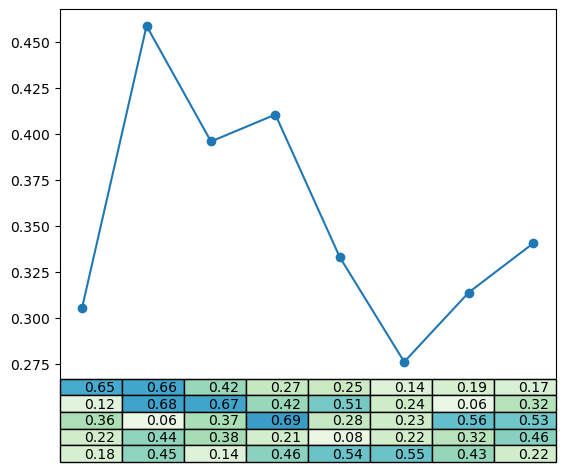

In [17]:
import pandas as pd
import numpy as np
 
x = np.random.rand(5, 8)*.7
plt.plot(x.mean(axis=0), '-o', label='average per column')
plt.xticks([])

#At least one of cellText or cellColours must be specified. 
plt.table(cellText=[['%1.2f' % xxx for xxx in xx] for xx in x],cellColours=plt.cm.GnBu(x),loc='bottom')
 
plt.show()

At least one of cellText or cellColours must be specified. For more details, see [matplotlib.table.table](https://matplotlib.org/3.5.1/api/table_api.html#:~:text=the%20cell%20boundary.-,matplotlib.table.table,-(ax%2C%20cellText%3DNone)

['%1.2f'](https://www.code2master.com/python/python-print-format/#:~:text=to%20the%20code2master!!-,Floating%20Point%20Numbers,-Floating%20point%20numbers): Floating point numbers use the format %n1.n2f where the n1 is the total minimum number of digits the string should contain (these may be filled with whitespace if the entire number does not have this many digits.) The n2 is for number of decimal places you want.